In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving winequality-red.csv to winequality-red (1).csv


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [ ]:
df.head()
print("Shape:", df.shape)

Shape: (1599, 12)


In [ ]:
df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))

Original rows: 1599
Rows after removing duplicates: 1359


In [ ]:
df_clean.describe().round(2)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00,1359.00
mean,8.31,0.53,0.27,2.52,0.09,15.89,46.83,1.00,3.31,0.66,10.43,5.62
std,1.74,0.18,0.20,1.35,0.05,10.45,33.41,0.00,0.16,0.17,1.08,0.82
min,4.60,0.12,0.00,0.90,0.01,1.00,6.00,0.99,2.74,0.33,8.40,3.00
25%,7.10,0.39,0.09,1.90,0.07,7.00,22.00,1.00,3.21,0.55,9.50,5.00
50%,7.90,0.52,0.26,2.20,0.08,14.00,38.00,1.00,3.31,0.62,10.20,6.00
75%,9.20,0.64,0.43,2.60,0.09,21.00,63.00,1.00,3.40,0.73,11.10,6.00
max,15.90,1.58,1.00,15.50,0.61,72.00,289.00,1.00,4.01,2.00,14.90,8.00


Descriptive Statistics – Key Insights

After removing duplicates, we have 1,359 wine records.

The average alcohol content is 10.43%.

Alcohol levels range from 8.4% to 14.9%.

Most wines have a quality rating around 5 or 6.

Overall, this summary helps me understand the data better before moving on to the machine learning model.

In [ ]:
# Count wines by quality score
quality_counts = df['quality'].value_counts().sort_index()

print(quality_counts)

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


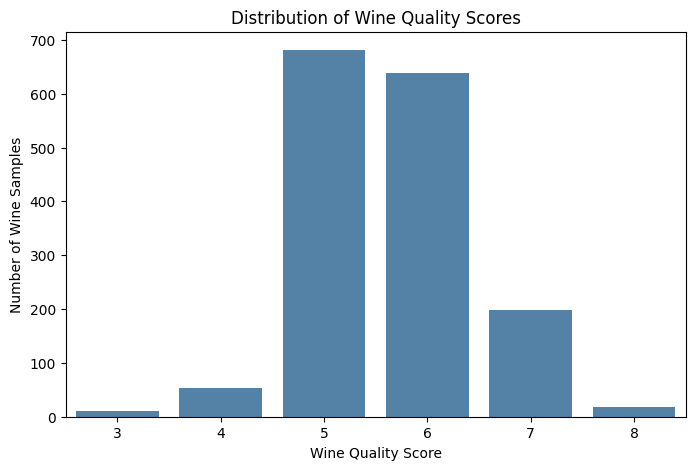

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='quality', color='steelblue')

plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Wine Quality Score')
plt.ylabel('Number of Wine Samples')

plt.show()

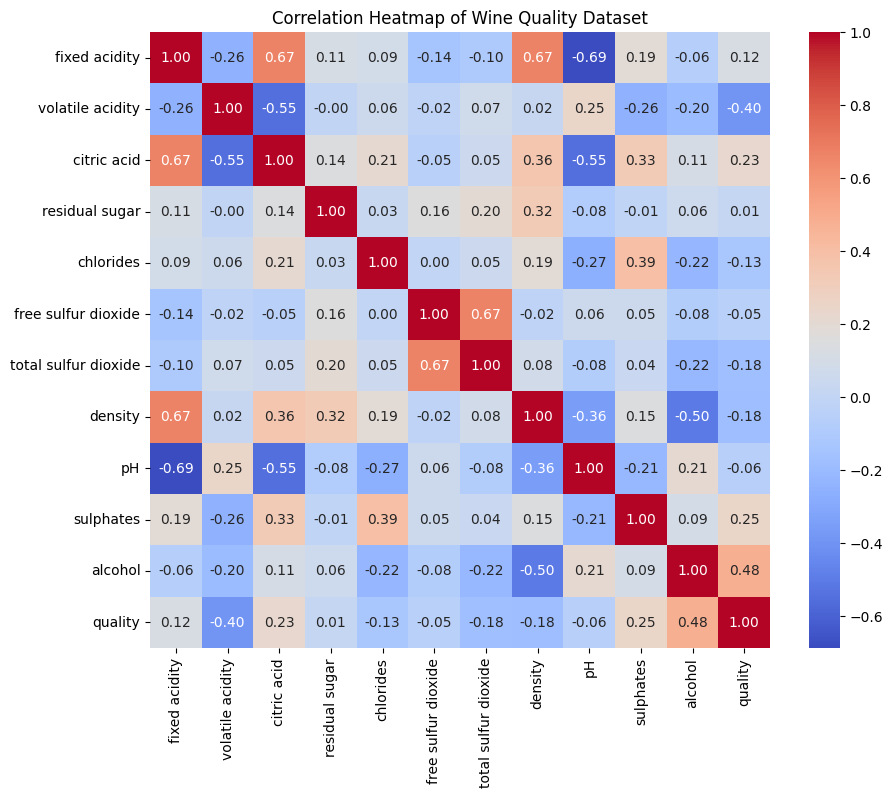

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = df_clean.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Wine Quality Dataset')
plt.show()

What I Learned from the Correlation Heatmap

Alcohol (0.48) has the strongest positive relationship with wine quality.

Volatile acidity (-0.40) has the strongest negative relationship.

Sulphates (0.25) and citric acid (0.23) show weaker positive relationships.

Most other features have a weak relationship with quality.

Overall, alcohol and volatile acidity show the clearest relationships with wine quality. However, correlation does not mean causation.

In [ ]:
X = df_clean.drop('quality', axis=1)
y = df_clean['quality']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1359, 11)
Target shape: (1359,)


In [ ]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (1087, 11)
Testing data: (272, 11)


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [ ]:
y_pred = model.predict(X_test)

print("Actual quality:", y_test.values[:10])
print("Predicted quality:", y_pred[:10].round(2))

Actual quality: [5 6 7 5 4 7 5 5 6 5]
Predicted quality: [5.25 5.81 6.37 5.16 5.2  6.78 5.71 4.84 5.8  5.74]


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("Mean Squared Error:", round(mse, 2))
print("R² Score:", round(r2, 2))

Mean Absolute Error: 0.5
Mean Squared Error: 0.43
R² Score: 0.39


What I learned from model evaluation

Mean Absolute Error (0.50): Predictions are off by about 0.5 quality points on average.

Mean Squared Error (0.43): Measures prediction errors, giving larger errors more weight.

R² Score (0.39): The model explains about 39% of the variation in wine quality scores.

Overall: Our Linear Regression model has learned some patterns, but there’s still room to improve its predictions.

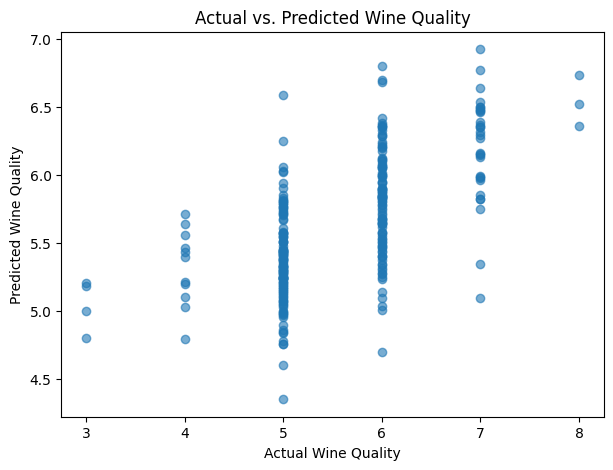

In [ ]:
plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred, alpha=0.6)
plt.xlabel("Actual Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("Actual vs. Predicted Wine Quality")

plt.show()

Overall, the model identifies some patterns in wine quality, but its predictions could be improved.

Conclusion

In this project, I explored a wine quality dataset and built a simple Linear Regression model to predict wine quality. I cleaned the data, explored relationships between features, trained the model, and evaluated its predictions.

The model achieved an MAE of 0.50 and an R² score of 0.39. This helped me understand how machine learning can be used to make predictions and how model performance can be evaluated.

Through this project, I gained practical experience in data analysis and the basics of machine learning.